In [2]:
!pip install datasets

In [3]:
pip install -U datasets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 21.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [4]:
from datasets import load_dataset

ds = load_dataset("roneneldan/TinyStories")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

In [5]:
!pip install tiktoken
import tiktoken
import os
import numpy as np
from tqdm.auto import tqdm

enc = tiktoken.get_encoding("gpt2")

# Some functions from https://github.com/karpathy/nanoGPT/blob/master/data/openwebtext/prepare.py

def process(example):
    ids = enc.encode_ordinary(example['text']) # encode_ordinary ignores any special tokens
    out = {'ids': ids, 'len': len(ids)}
    return out

if not os.path.exists("train.bin"):
    tokenized = ds.map(
        process,
        remove_columns=['text'],
        desc="tokenizing the splits",
        num_proc=8,
        )
    # concatenate all the ids in each dataset into one large file we can use for training
    for split, dset in tokenized.items():
        arr_len = np.sum(dset['len'], dtype=np.uint64)
        filename = f'{split}.bin'
        dtype = np.uint16 # (can do since enc.max_token_value == 50256 is < 2**16)
        arr = np.memmap(filename, dtype=dtype, mode='w+', shape=(arr_len,))
        total_batches = 1024

        idx = 0
        for batch_idx in tqdm(range(total_batches), desc=f'writing {filename}'):
            # Batch together samples for faster write
            batch = dset.shard(num_shards=total_batches, index=batch_idx, contiguous=True).with_format('numpy')
            arr_batch = np.concatenate(batch['ids'])
            # Write into mmap
            arr[idx : idx + len(arr_batch)] = arr_batch
            idx += len(arr_batch)
        arr.flush()

tokenizing the splits (num_proc=8):   0%|          | 0/2119719 [00:00<?, ? examples/s]

tokenizing the splits (num_proc=8):   0%|          | 0/21990 [00:00<?, ? examples/s]

writing train.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

writing validation.bin:   0%|          | 0/1024 [00:00<?, ?it/s]

In [6]:
# Some functions from https://github.com/karpathy/nanoGPT/blob/master/train.py with slight modifications
#block size = context window
def get_batch(split):
    # We recreate np.memmap every batch to avoid a memory leak, as per
    # https://stackoverflow.com/questions/45132940/numpy-memmap-memory-usage-want-to-iterate-once/61472122#61472122
    if split == 'train':
        data = np.memmap('train.bin', dtype=np.uint16, mode='r')
    else:
        data = np.memmap('validation.bin', dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        # pin arrays x,y, which allows us to move them to GPU asynchronously (non_blocking=True)
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
import numpy as np
from tqdm.auto import tqdm
from contextlib import nullcontext
import os

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                       .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None, dropout_p=self.attn_dropout.p if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2 = LayerNorm(config.n_embd, config.bias)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int
    vocab_size: int
    n_layer: int
    n_head: int
    n_embd: int
    dropout: float = 0.0
    bias: bool = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            logits = self.lm_head(x[:, [-1], :])
            return logits, None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        """
        Generate tokens given a conditioning sequence.
        idx: Tensor of shape (B, T)
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx



In [8]:
config = GPTConfig(
    vocab_size=50257,     # use the tokenizer's vocab size
    block_size=128,       # or whatever context size you're training with
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.1,
    bias=True
)

model = GPT(config)

In [9]:
def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    logits, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

In [10]:
# Training Config
import torch
from contextlib import nullcontext

learning_rate = 1e-4 #more stable training, earlier 1e-4
max_iters = 20000 #increase from 25000
warmup_steps = 1000 #smoother initial train, earlier 100
min_lr = 5e-4 #lower rate, earlier 5e-4
eval_iters = 500 # increased from 100
batch_size = 32 # changed from 16, better gradient estimate
block_size = 128 #changed from 64, capture longer range dependencies

gradient_accumulation_steps = 32 # reduced from 50

device =  "cuda" if torch.cuda.is_available() else "cpu"
device_type = 'cuda' if 'cuda' in device else 'cpu' # for later use in torch.autocast
# note: float16 data type will automatically use a GradScaler

# How to use autocast https://wandb.ai/wandb_fc/tips/reports/How-To-Use-Autocast-in-PyTorch--VmlldzoyMTk4NTky
#dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
dtype = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16' # 'float32', 'bfloat16', or 'float16', the latter will auto implement a GradScaler
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

ctx = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)

torch.set_default_device(device)
torch.manual_seed(42)

In [11]:
from torch.optim.lr_scheduler import LinearLR,SequentialLR, CosineAnnealingLR

##PUT IN WEIGHT DECAY, CHANGED BETA2 to 0.95
optimizer =  torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9) #weight decay for regularization

scheduler_warmup = LinearLR(optimizer, total_iters = warmup_steps) #Implement linear warmup
scheduler_decay = CosineAnnealingLR(optimizer,T_max = max_iters - warmup_steps, eta_min = min_lr) #Implement lr decay
scheduler = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay], milestones=[warmup_steps]) #Switching from warmup to decay

# https://stackoverflow.com/questions/72534859/is-gradscaler-necessary-with-mixed-precision-training-with-pytorch
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))

/tmp/ipykernel_807/2132813893.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


In [12]:
best_val_loss = float('inf')
best_model_params_path = "best_model_params.pt"
train_loss_list, validation_loss_list = [], []

# Ensure model is on the correct device
model = model.to(device)

# In your training loop
for epoch in tqdm(range(max_iters)):
    if epoch % eval_iters == 0 and epoch != 0:
        # Ensure estimate_loss uses the correct device
        losses = estimate_loss(model)
        print(f"Epoch {epoch}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")
        print(f"The current learning rate: {optimizer.param_groups[0]['lr']:.5f}")
        train_loss_list += [losses['train']]
        validation_loss_list += [losses['val']]

        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save(model.state_dict(), best_model_params_path)

    # Ensure X and y are on the correct device
    X, y = get_batch("train")
    X, y = X.to(device), y.to(device)

    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

  0%|          | 0/20000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


KeyboardInterrupt: 

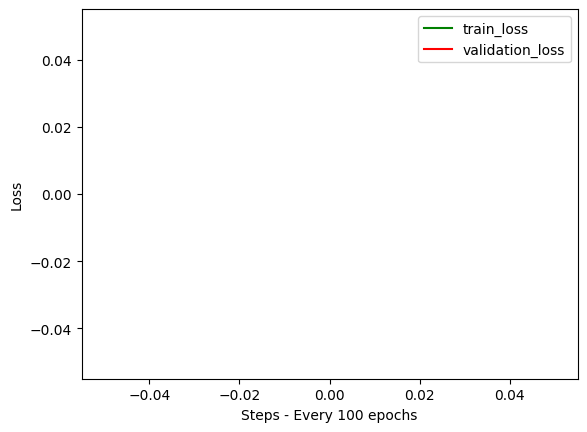

In [13]:
import matplotlib.pyplot as plt
train_loss_list_converted = [i.cpu().detach() for i in train_loss_list]
validation_loss_list_converted = [i.cpu().detach() for i in validation_loss_list]

plt.plot(train_loss_list_converted, 'g', label='train_loss')
plt.plot(validation_loss_list_converted, 'r', label='validation_loss')
plt.xlabel("Steps - Every 100 epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()



In [14]:
#Load the model
model = GPT(config)  # re-create the model with same config
device =  "cuda" if torch.cuda.is_available() else "cpu"
best_model_params_path = "best_model_params.pt"
model.load_state_dict(torch.load(best_model_params_path, map_location=torch.device(device))) # load best model states


FileNotFoundError: [Errno 2] No such file or directory: 'best_model_params.pt'

In [ ]:
sentence = "Once upon a time there was a pumpkin."
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

In [ ]:
sentence = "A little girl went to the woods"
context = (torch.tensor(enc.encode_ordinary(sentence)).unsqueeze(dim = 0))
y = model.generate(context, 200)
print(enc.decode(y.squeeze().tolist()))

In [15]:
from google.colab import runtime
runtime.unassign()

In [1]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import torch

In [2]:
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Orbitron:wght@400;700;900&family=Exo+2:wght@300;400;600;700&display=swap');

.tt-wrap * { box-sizing: border-box; }

.tt-wrap {
  font-family: 'Exo 2', sans-serif;
  background: #000;
  border-radius: 20px;
  padding: 30px 26px 24px;
  max-width: 660px;
  margin: 16px auto;
  position: relative;
  overflow: hidden;
  border: 1px solid rgba(0,245,255,0.2);
  box-shadow: 0 0 60px rgba(0,245,255,0.08), 0 0 120px rgba(191,0,255,0.05);
}

.tt-wrap canvas {
  position: absolute;
  top: 0; left: 0;
  width: 100%; height: 100%;
  pointer-events: none;
  z-index: 0;
}

.tt-content { position: relative; z-index: 1; }

.tt-logo {
  font-family: 'Orbitron', monospace;
  font-size: 32px;
  font-weight: 900;
  letter-spacing: 4px;
  text-align: center;
  background: linear-gradient(90deg,#00f5ff,#bf00ff,#ff006e,#00f5ff);
  background-size: 300%;
  -webkit-background-clip: text;
  -webkit-text-fill-color: transparent;
  background-clip: text;
  animation: chroma 4s linear infinite;
  margin-bottom: 4px;
}
@keyframes chroma { 0%{background-position:0%} 100%{background-position:300%} }

.tt-sub {
  text-align: center;
  font-size: 11px;
  color: rgba(0,245,255,0.45);
  letter-spacing: 2.5px;
  text-transform: uppercase;
  margin-bottom: 20px;
  font-weight: 600;
}

.tt-scan-line {
  width: 100%;
  height: 1px;
  background: linear-gradient(90deg,transparent,#00f5ff,transparent);
  animation: scanpulse 3s ease-in-out infinite;
  margin-bottom: 22px;
}
@keyframes scanpulse { 0%,100%{opacity:0.2;transform:scaleX(0.3)} 50%{opacity:1;transform:scaleX(1)} }

.tt-section {
  font-size: 10px;
  font-weight: 700;
  letter-spacing: 2px;
  color: #00f5ff;
  text-transform: uppercase;
  margin-bottom: 10px;
  display: flex;
  align-items: center;
  gap: 8px;
}
.tt-section::before { content:''; width:14px; height:1px; background:#00f5ff; }
.tt-section::after  { content:''; flex:1; height:1px; background:linear-gradient(90deg,#00f5ff,transparent); }

.tt-story-box {
  background: rgba(0,0,0,0.7);
  border: 1px solid rgba(0,245,255,0.3);
  border-radius: 16px;
  padding: 22px;
  margin-top: 18px;
  position: relative;
  overflow: hidden;
  animation: emerge .5s ease;
}
@keyframes emerge { from{opacity:0;transform:translateY(10px)} to{opacity:1;transform:translateY(0)} }

.tt-story-box::before {
  content: '';
  position: absolute;
  top: 0; left: 0; right: 0;
  height: 1px;
  background: linear-gradient(90deg,transparent,#00f5ff,#bf00ff,transparent);
  animation: topscan 3s ease-in-out infinite;
}
@keyframes topscan { 0%,100%{opacity:.3} 50%{opacity:1} }

.tt-corner { position:absolute; width:12px; height:12px; border-color:#00f5ff; border-style:solid; }
.tt-corner.tl { top:8px;left:8px; border-width:2px 0 0 2px; }
.tt-corner.tr { top:8px;right:8px; border-width:2px 2px 0 0; }
.tt-corner.bl { bottom:8px;left:8px; border-width:0 0 2px 2px; }
.tt-corner.br { bottom:8px;right:8px; border-width:0 2px 2px 0; }

.tt-story-title {
  font-family: 'Orbitron', monospace;
  font-size: 15px;
  color: #00f5ff;
  text-align: center;
  margin-bottom: 14px;
  letter-spacing: 1px;
}
.tt-story-text {
  font-size: 14px;
  line-height: 1.9;
  color: rgba(255,255,255,0.9);
}
.tt-badge {
  display: inline-block;
  background: rgba(0,245,255,0.08);
  border: 1px solid rgba(0,245,255,0.25);
  border-radius: 20px;
  padding: 4px 12px;
  font-size: 10px;
  font-weight: 700;
  color: #00f5ff;
  letter-spacing: 1px;
  text-transform: uppercase;
  margin-top: 14px;
}
.tt-foot {
  text-align: center;
  margin-top: 16px;
  font-size: 10px;
  color: rgba(255,255,255,0.18);
  letter-spacing: 1.5px;
  text-transform: uppercase;
}
.tt-foot span { color: rgba(0,245,255,0.35); }

/* Widget overrides for dark theme */
.widget-toggle-buttons .p-ToggleButton {
  background: rgba(0,245,255,0.04) !important;
  border: 1px solid rgba(0,245,255,0.2) !important;
  color: rgba(0,245,255,0.75) !important;
  font-family: 'Exo 2', sans-serif !important;
  font-size: 11px !important;
  font-weight: 700 !important;
  letter-spacing: 0.5px !important;
  border-radius: 8px !important;
  transition: all .2s !important;
  text-transform: uppercase !important;
}
.widget-toggle-buttons .p-ToggleButton.p-mod-toggled,
.widget-toggle-buttons .p-ToggleButton:hover {
  background: rgba(0,245,255,0.12) !important;
  border-color: rgba(0,245,255,0.7) !important;
  color: #00f5ff !important;
  box-shadow: 0 0 12px rgba(0,245,255,0.25) !important;
}
.widget-slider .noUi-connect { background: linear-gradient(90deg,#00f5ff,#bf00ff) !important; }
.widget-button button {
  background: transparent !important;
  border: 2px solid #00f5ff !important;
  border-radius: 12px !important;
  color: #00f5ff !important;
  font-family: 'Orbitron', monospace !important;
  font-size: 13px !important;
  font-weight: 700 !important;
  letter-spacing: 2px !important;
  padding: 12px 24px !important;
  cursor: pointer !important;
  text-transform: uppercase !important;
  transition: all .3s !important;
  width: 100% !important;
}
.widget-button button:hover {
  box-shadow: 0 0 24px rgba(0,245,255,0.5), 0 0 48px rgba(0,245,255,0.2) !important;
  background: rgba(0,245,255,0.08) !important;
  transform: translateY(-2px) !important;
}
</style>

<script>
(function(){
  function initCanvas(wrapId) {
    const wrap = document.querySelector('.tt-wrap');
    if (!wrap) { setTimeout(()=>initCanvas(wrapId), 200); return; }
    const c = document.createElement('canvas');
    wrap.insertBefore(c, wrap.firstChild);
    const ctx = c.getContext('2d');
    c.width = wrap.offsetWidth; c.height = wrap.offsetHeight;
    const stars = Array.from({length:80},()=>({x:Math.random()*c.width,y:Math.random()*c.height,r:Math.random()*1.4+0.3,a:Math.random(),da:0.004+Math.random()*0.009}));
    const pts   = Array.from({length:16},()=>({x:Math.random()*c.width,y:Math.random()*c.height,vx:(Math.random()-.5)*.35,vy:(Math.random()-.5)*.35}));
    function draw(){
      ctx.clearRect(0,0,c.width,c.height);
      ctx.fillStyle='#000'; ctx.fillRect(0,0,c.width,c.height);
      stars.forEach(s=>{
        s.a+=s.da; if(s.a>1||s.a<0)s.da*=-1;
        ctx.beginPath(); ctx.arc(s.x,s.y,s.r,0,Math.PI*2);
        ctx.fillStyle='rgba(0,245,255,'+s.a*0.65+')'; ctx.fill();
      });
      pts.forEach(p=>{p.x+=p.vx;p.y+=p.vy;if(p.x<0||p.x>c.width)p.vx*=-1;if(p.y<0||p.y>c.height)p.vy*=-1;});
      pts.forEach((a,i)=>pts.slice(i+1).forEach(b=>{
        const d=Math.hypot(a.x-b.x,a.y-b.y);
        if(d<110){ctx.beginPath();ctx.moveTo(a.x,a.y);ctx.lineTo(b.x,b.y);ctx.strokeStyle='rgba(191,0,255,'+(1-d/110)*0.3+')';ctx.lineWidth=0.5;ctx.stroke();}
      }));
      requestAnimationFrame(draw);
    }
    draw();
  }
  setTimeout(()=>initCanvas(),400);
})();
</script>
"""))

# ── Character & Theme data ────────────────────────────────────────
characters = {
    "🐰 Bunny":    "Once upon a time, a brave little bunny",
    "🐘 Elephant": "Once upon a time, a curious elephant",
    "🐲 Dragon":   "Once upon a time, a tiny friendly dragon",
    "🐻 Bear":     "Once upon a time, a cozy little bear",
    "🐱 Cat":      "Once upon a time, a magical cat",
    "🦉 Owl":      "Once upon a time, a wise friendly owl",
    "🐸 Frog":     "Once upon a time, a silly happy frog",
    "🦁 Lion":     "Once upon a time, a gentle kind lion",
}

themes = {
    "🤝 Friendship":  "made a new friend and learned about sharing.",
    "🌲 Adventure":   "went on a magical forest adventure.",
    "🌙 Bedtime":     "found the perfect place to sleep and dream.",
    "⭐ Bravery":     "did something brave they never thought possible.",
    "💛 Kindness":    "helped a little creature who needed a friend.",
    "🎨 Learning":    "discovered something wonderful and brand new.",
}

# ── Widgets ───────────────────────────────────────────────────────
char_label = widgets.HTML("""
<div class="tt-wrap">
  <div class="tt-content">
    <div class="tt-logo">✦ TINY TALES ✦</div>
    <div class="tt-sub">Neural Story Generator · SLM v1.0</div>
    <div class="tt-scan-line"></div>
  </div>
</div>""")

char_section  = widgets.HTML('<div class="tt-section">Select hero unit</div>')
char_select   = widgets.ToggleButtons(options=list(characters.keys()), value="🐰 Bunny",
                                       layout=widgets.Layout(width='100%'))

theme_section = widgets.HTML('<div class="tt-section" style="margin-top:14px">Story theme</div>')
theme_select  = widgets.ToggleButtons(options=list(themes.keys()), value="🤝 Friendship",
                                       layout=widgets.Layout(width='100%'))

sliders_section = widgets.HTML('<div class="tt-section" style="margin-top:14px">Parameters</div>')
temp_slider   = widgets.FloatSlider(value=0.8, min=0.5, max=1.4, step=0.05,
                                    description="🌡 Creativity:", readout=True, readout_format='.2f',
                                    style={'description_width':'120px','handle_color':'#00f5ff'},
                                    layout=widgets.Layout(width='100%'))
tokens_slider = widgets.IntSlider(value=200, min=80, max=350, step=10,
                                   description="📏 Length (tokens):", readout=True,
                                   style={'description_width':'120px','handle_color':'#bf00ff'},
                                   layout=widgets.Layout(width='100%'))

gen_btn    = widgets.Button(description="⚡  GENERATE STORY",
                             layout=widgets.Layout(width='100%', height='52px'),
                             style={'font_weight':'bold'})
output_out = widgets.Output()

# ── Generation logic ──────────────────────────────────────────────
def on_generate(b):
    with output_out:
        clear_output(wait=True)
        display(HTML("""
        <div style="text-align:center;padding:20px 0;font-family:'Exo 2',sans-serif">
          <div style="width:44px;height:44px;border:2px solid rgba(0,245,255,0.15);border-top:2px solid #00f5ff;border-right:2px solid #bf00ff;border-radius:50%;animation:spin 1s linear infinite;margin:0 auto 12px"></div>
          <p style="font-size:11px;color:rgba(0,245,255,0.6);letter-spacing:2px;text-transform:uppercase;animation:blink 1.2s infinite">
            Neural network processing...
          </p>
          <style>
            @keyframes spin{to{transform:rotate(360deg)}}
            @keyframes blink{0%,100%{opacity:.3}50%{opacity:1}}
          </style>
        </div>"""))

    char_prompt  = characters[char_select.value]
    theme_end    = themes[theme_select.value]
    prompt_text  = f"{char_prompt} who {theme_end} One day,"

    context = torch.tensor(enc.encode_ordinary(prompt_text)).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out_ids = model.generate(
            context,
            max_new_tokens=tokens_slider.value,
            temperature=float(temp_slider.value),
            top_k=40
        )

    story = enc.decode(out_ids.squeeze().tolist()).strip()
    # Trim to last complete sentence
    for punct in ['. ', '! ', '? ']:
        last = story.rfind(punct)
        if last > len(story) // 2:
            story = story[:last + 1]
            break

    char_icon  = char_select.value.split()[0]
    theme_icon = theme_select.value.split()[0]
    temp_val   = f"{temp_slider.value:.2f}"
    tok_val    = tokens_slider.value

    with output_out:
        clear_output(wait=True)
        display(HTML(f"""
        <div class="tt-story-box">
          <div class="tt-corner tl"></div>
          <div class="tt-corner tr"></div>
          <div class="tt-corner bl"></div>
          <div class="tt-corner br"></div>
          <div class="tt-story-title">✦ {char_icon} A Tiny Tale {theme_icon} ✦</div>
          <div class="tt-story-text">{story}</div>
          <div><span class="tt-badge">Ages 3–4 &nbsp;·&nbsp; Temp {temp_val} &nbsp;·&nbsp; {tok_val} tokens</span></div>
        </div>
        <div class="tt-foot" style="margin-top:12px">
          Generated by your <span>GPT SLM</span> trained on the TinyStories dataset
        </div>
        """))

gen_btn.on_click(on_generate)

In [3]:
#assemble and display
ui = widgets.VBox([
    char_label,
    widgets.VBox([
        char_section, char_select,
        theme_section, theme_select,
        sliders_section, temp_slider, tokens_slider,
        widgets.Box([gen_btn], layout=widgets.Layout(margin='14px 0 0 0')),
        output_out
    ], layout=widgets.Layout(padding='0 4px'))
], layout=widgets.Layout(max_width='660px', margin='0 auto'))

display(ui)

NameError: name 'enc' is not defined